In [ ]:
from flask import Flask, request, jsonify
from docx import Document
import chromadb
import torch
import os
from transformers import AutoTokenizer, AutoModelForCausalLM
from sentence_transformers import SentenceTransformer, models
import mysql.connector
import PyPDF2
import pandas as pd
from datetime import datetime

**模組與其功能做說明，方便你了解它們在程式中扮演的角色：**

1.from flask import Flask, request, jsonify
Flask：輕量級的 Python Web 框架，用於建立 RESTful API 或網頁應用。
request：取得客戶端送來的 HTTP 請求資料（如 URL 參數、表單、JSON）。
jsonify：將 Python 資料結構轉成 JSON 回應，並設定適當的 HTTP header。


2.from docx import Document
Document：來自 python‑docx 套件，可用於讀取、解析與操作 .docx（Word）檔案內容。


3.import chromadb
chromadb：輕量的向量資料庫客戶端，用於儲存與查詢文本嵌入（embeddings），是實現檢索增強生成（RAG）系統的核心組件之一。

4.import torch
torch：PyTorch 深度學習框架的核心庫，提供張量運算、GPU 加速與自動微分功能，常用於載入與運行大型語言模型。

5.import os
os：Python 標準庫，提供路徑操作、檔案與目錄管理、環境變數讀取等系統層級功能。

6.from transformers import AutoTokenizer, AutoModelForCausalLM
AutoTokenizer：自動下載並初始化與指定模型相容的分詞器（tokenizer）。
AutoModelForCausalLM：自動下載並載入自回歸（causal）語言模型，用於文字生成任務。

7.from sentence_transformers import SentenceTransformer, models
SentenceTransformer：封裝多層 Transformer + Pooling，將文字轉換成固定維度的句向量（embeddings）。
models：提供底層模組如 Transformer（載入預訓練模型）與 Pooling（向量彙整方式）。

8.import mysql.connector
mysql.connector：MySQL 官方提供的 Python 連線器，用於在程式中執行 SQL 查詢、管理事務與連線池等。

9.import PyPDF2
PyPDF2：處理 PDF 檔案的套件，支援讀取、抽取文字、分割與合併頁面等基本操作。

10.import pandas as pd
pandas：強大的資料處理與分析工具，特別擅長讀取 Excel 檔（.xlsx, .xls）、CSV，以及進行資料清理、篩選與轉換。

11.from datetime import datetime
datetime：Python 標準庫中的日期時間類別，用於標記記錄生成時間、計算時間差或格式化輸出。

In [ ]:
app = Flask(__name__)

與前端界面傳輸文字內容


In [ ]:
EMBEDDING_MODEL_PATH = "intfloat/multilingual-e5-large"
LLM_MODEL_PATH = "MediaTek-Research/Breeze-7B-Instruct-v1_0"

本地部署：嵌入式模型與大語言模型

In [ ]:
class RAGServer:
    def __init__(self):
        self.embedder = None
        self.llm = None
        self.collection = None
        self.db_config = {
            'host': 'localhost',
            'user': 'root',
            'password': '12345',
            'database': 'chatbot',
            'charset': 'utf8mb4'
        }
        self._initialize_components()
        self._init_database_table()

這段程式碼的主要作用，是在建立 RAGServer 物件時，一次完成所有必要的環境與資源準備，保證後續問答服務可以立即運行。具體來說，它包含以下關鍵功能：

1.預先保留核心元件的佔位符
self.embedder、self.llm、self.collection 初始皆設為 None，分別對應文本向量化模型、語言生成模型與向量資料庫。這樣的設計可讓後續方法統一對這三個屬性進行載入與賦值，不必在其他地方反覆檢查或手動指定。



2.定義資料庫連線參數
self.db_config 內部以字典形式一次列出 MySQL 主機位址、使用者帳號、密碼、資料庫名稱以及字元編碼。集中管理可降低漏寫或不一致的風險，也便於將來修改連線資訊。


3.模型與資料庫元件的一鍵初始化
呼叫 self._initialize_components()：
載入並建置「嵌入模型」（SentenceTransformer）
載入並建置「語言模型」（AutoModelForCausalLM + Tokenizer）
建立並填充「ChromaDB 向量資料庫」，將所有訓練資料文件轉成向量後加入庫中
若任一步驟發生錯誤，就會立即印出錯誤原因並中斷服務啟動，避免後續請求無法正常處理。


5.自動建立與檢查資料表結構
呼叫 self._init_database_table()：
連線到剛才設定的 MySQL
建立必要的 chat_data 表格（含自增主鍵、問題、回答、時間戳）
如表格已存在則跳過，確保每次啟動都不需手動操做資料庫外掛

In [ ]:
def _initialize_components(self):
        """初始化所有组件并处理异常"""
        try:

            self.embedder = self._init_embedder()

            self.llm = self._init_llm()

            self.collection = self._init_database()

            print("系統初始化完成！")
        except Exception as e:
            print(f"初始化失敗: {str(e)}")
            raise RuntimeError("服務器啟動失敗，請檢查文件")

依序載入：
*   文本向量化模型（embedder）
*   自回歸語言生成模型與分詞器（LLM）
*   建置並填充向量資料庫（ChromaDB collection）

全部成功後顯示「系統初始化完成！」

任一環節失敗，印出錯誤並拋出例外，終止伺服器啟動。

In [ ]:
def _init_embedder(self):

        print("正在加载模型...")
        device = "cuda" if torch.cuda.is_available() else "cpu"
        word_embedding_model = models.Transformer(EMBEDDING_MODEL_PATH)
        pooling_model = models.Pooling(word_embedding_model.get_word_embedding_dimension())
        return SentenceTransformer(
            modules=[word_embedding_model, pooling_model],
            device=device
        )

這個方法的主要作用是建立「句向量嵌入器」，步驟如下：
1.   顯示載入訊息
*   印出「正在加载模型...」，提示使用者進入向量化模型載入階段。
2.   選擇運算裝置
*   若有可用 GPU（torch.cuda.is_available()），則將裝置設為 cuda，否則使用 cpu。
3.   載入 Transformer 層
*   models.Transformer(EMBEDDING_MODEL_PATH)：從指定路徑載入預訓練的詞向量模型。
4.   加入 Pooling 層
*   models.Pooling(...)：根據 Transformer 的輸出向量維度，將詞向量彙整成固定長度的句向量（常用均值、最大值等策略）。
5.   組合成 SentenceTransformer 實例
*   SentenceTransformer(modules=[…], device=device)：將上述兩層串接，並指定運算裝置，回傳可直接呼叫 .encode(text) 產生句向量的物件。





In [ ]:
 def _init_llm(self):

        print("正在載入語言模型...")
        device = "cuda" if torch.cuda.is_available() else "cpu"
        tokenizer = AutoTokenizer.from_pretrained(LLM_MODEL_PATH)
        model = AutoModelForCausalLM.from_pretrained(
            LLM_MODEL_PATH,
            torch_dtype=torch.float16 if device == "cuda" else torch.float32,
            device_map="auto"
        )
        return {"tokenizer": tokenizer, "model": model}

載入「自回歸語言生成模型」與對應的分詞器，步驟如下：

1.   提示訊息
*   印出「正在載入語言模型…」，告知使用者進入模型載入階段。
2.   選擇運算裝置
*   若有 GPU，使用 cuda；否則使用 cpu，以決定後續運算的硬體。
3.   載入分詞器（Tokenizer）
*   AutoTokenizer.from_pretrained(LLM_MODEL_PATH)：自動下載並初始化與指定模型相符的分詞器，用於將文字轉換為 token。
4.   載入模型
*   utoModelForCausalLM.from_pretrained(...)：下載並載入自回歸語言模型，若使用 GPU，模型將以半精度（float16）載入以節省顯存；否則以單精度（float32）載入。
device_map="auto" 用於自動分配模型到可用裝置。
5.   回傳組合
*   回傳一個字典 {"tokenizer": tokenizer, "model": model}，後續會共同用於構建 prompt、編碼輸入並生成回答。

In [ ]:
def _init_database(self):

        print("正在初始化資料庫...")
        client = chromadb.Client()
        collection = client.get_or_create_collection(name="docx_collection")
        data_dir = r'C:\Users\user\Desktop\web\訓練資料R'

        for filename in os.listdir(data_dir):
            file_path = os.path.join(data_dir, filename)
            chunks = []

            # 不同文件類型選擇的讀取方法
            if filename.endswith('.docx'):
                chunks = self._read_and_split_docx(file_path)
            elif filename.endswith('.pdf'):
                chunks = self._read_and_split_pdf(file_path)
            elif filename.endswith('.txt'):
                chunks = self._read_and_split_txt(file_path)
            elif filename.endswith(('.xlsx', '.xls')):
                chunks = self._read_and_split_excel(file_path)

            # 將內容添加到資料庫
            for idx, chunk in enumerate(chunks):
                if chunk.strip():  # 確保內容不為空
                    embedding = self.embedder.encode(chunk).tolist()
                    collection.add(
                        ids=[f"{filename}_{idx}"],
                        embeddings=[embedding],
                        documents=[chunk]
                    )
        return collection

「建立並填充向量資料庫」，流程與作用可分為：

1.   建立 ChromaDB 客戶端與 Collection
*   使用 chromadb.Client() 連線到本地向量資料庫

* 呼叫 get_or_create_collection("docx_collection")：

*  若該 collection 已存在則直接取得，否則新建一個名為 docx_collection 的向量集
2.   遍歷訓練資料資料夾
*   固定路徑 C:\Users\user\Desktop\web\訓練資料R
*   透過 os.listdir 取得所有檔案名稱，逐一處理
3.   依副檔名選擇適當的讀取與切分函式
*   .docx → _read_and_split_docx

*   .pdf → _read_and_split_pdf

*   .txt → _read_and_split_txt

*   .xlsx/.xls → _read_and_split_excel

*   將每支檔案拆成「多段文字塊（chunk）」，以利後續向量化與檢索
4.   向量化並加入資料庫
*   對每個不為空的文字塊：


1.   呼叫 self.embedder.encode(chunk) 將文字轉成向量
2.   以 collection.add(...) 新增記錄，包含：
*   ids：檔名_段落索引
*   embeddings：剛產生的向量列表
* documents：原始文字內容
5.   回傳已建置好的 Collection
*   最後 return collection，讓呼叫者能用它來執行後續的相似度查詢（RAG 檢索步驟）。





In [ ]:
  def _read_and_split_docx(self, file_path):
        """讀取docx文件"""
        doc = Document(file_path)
        return [para.text for para in doc.paragraphs if para.text.strip()]

    def _read_and_split_pdf(self, file_path):
        """讀取PDF文件"""
        chunks = []
        try:
            with open(file_path, 'rb') as file:
                pdf_reader = PyPDF2.PdfReader(file)
                for page in pdf_reader.pages:
                    text = page.extract_text()
                    if text:
                        paragraphs = text.split('\n\n')
                        chunks.extend([p.strip() for p in paragraphs if p.strip()])
        except Exception as e:
            print(f"讀取PDF文件 {file_path} 時出錯: {str(e)}")
        return chunks

    def _read_and_split_txt(self, file_path):
        """讀取TXT文件"""
        chunks = []
        try:
            with open(file_path, 'r', encoding='utf-8') as file:
                text = file.read()
                paragraphs = text.split('\n\n')
                chunks.extend([p.strip() for p in paragraphs if p.strip()])
        except UnicodeDecodeError:
            try:
                with open(file_path, 'r', encoding='big5') as file:
                    text = file.read()
                    paragraphs = text.split('\n\n')
                    chunks.extend([p.strip() for p in paragraphs if p.strip()])
            except Exception as e:
                print(f"讀取TXT文件 {file_path} 時出錯: {str(e)}")
        except Exception as e:
            print(f"讀取TXT文件 {file_path} 時出錯: {str(e)}")
        return chunks

    def _read_and_split_excel(self, file_path):
        """讀取Excel文件"""
        chunks = []
        try:
            df_list = pd.read_excel(file_path, sheet_name=None)
            for sheet_name, df in df_list.items():
                chunks.append(f"Sheet: {sheet_name}")
                columns = df.columns.tolist()
                for index, row in df.iterrows():
                    row_text = " | ".join([f"{col}: {row[col]}" for col in columns])
                    chunks.append(row_text)
                chunks.append("-" * 50)
        except Exception as e:
            print(f"讀取Excel文件 {file_path} 時出錯: {str(e)}")
        return chunks

「將各種格式的文件讀取並切分成合適的文字段落（chunk）」，以便後續向量化處理與檢索。具體功能如下：


1.   _read_and_split_docx(self, file_path)

*   用途：讀取 Microsoft Word（.docx）文件。
*   實作概要：利用 python‑docx 的 Document 類別開啟檔案，遍歷每個段落（paragraph），過濾掉空白段落後，回傳一個文字列表。

2.   _read_and_split_pdf(self, file_path)
*   用途：讀取 PDF 文件。
*   實作概要：用 PyPDF2.PdfReader 逐頁擷取文字，並以雙換行 ('\n\n') 分段；若有讀取錯誤，會印出錯誤訊息並跳過該檔案，最後回傳所有 non-empty 段落。

3.   _read_and_split_txt(self, file_path)
*   用途：讀取純文字（.txt）文件，支援 UTF-8 及 Big5 兩種編碼。
實作概要：
*   先以 UTF-8 開啟，若遇到 UnicodeDecodeError 再以 Big5 嘗試。
*  擷取全文後以雙換行拆分，並過濾空白段落；出錯時印錯誤訊息。

4.   _read_and_split_excel(self, file_path)
*   用途：讀取 Excel（.xlsx / .xls）檔案，提取所有工作表與儲存格內容。

實作概要：
*   用 pandas.read_excel(..., sheet_name=None) 同時載入所有工作表。
*   依序將每張工作表標題 (Sheet: 名稱) 加入 chunk，再將每列資料格式化為 "欄位: 值 | 欄位: 值"，最後以分隔線標示表尾。
*  如遇錯誤則印出訊息，並回傳已成功擷取的段落。



透過這套「格式識別→讀取→段落切分→過濾空白」流程，能確保後續的向量化階段，所有輸入皆為有效且具語意完整性的文字段落。


In [ ]:
  def generate_answer(self, question: str):
        """生成回答的完整流程（增強檢索 + 調整長度累積邏輯）"""
        try:
            # 產生 query 向量
            embedding = self.embedder.encode(question).tolist()


問題向量化
*  將使用者輸入的文字 question 透過已初始化的 SentenceTransformer 物件轉成數值向量，供後續相似度檢索使用。

In [ ]:

            results = self.collection.query(
                query_embeddings=[embedding],
                n_results=20,
                include=["documents", "distances"]
            )
            retrieved_docs = results.get('documents', [[]])[0]
            distances = results.get('distances', [[]])[0]



向量檢索
*  在 ChromaDB 中，以剛產生的向量作為查詢，取出與之最相似的前 20 筆文件片段（documents）及其距離（distances）。

In [ ]:

            context_docs = []
            total_length = 0
            if retrieved_docs and distances and len(retrieved_docs) == len(distances):
                sorted_results = sorted(zip(retrieved_docs, distances), key=lambda x: x[1])
                for doc, dist in sorted_results:
                    context_docs.append(doc)
                    total_length += len(doc)
                    print(f"添加文檔: 距離={dist:.4f}, 長度={len(doc)}, 總長={total_length}")
                    if total_length > 1000:
                        break
            else:
                context_docs = retrieved_docs[:3]



累積長度邏輯
*  排序：先依「距離由小到大」排序，確保最相關的片段優先被取用。

*  累積：逐筆加入 context_docs，同時計算加入後的總字元數，直到超過 1000 才停止，確保上下文足夠豐富。

*  備援：若檢索結果有異常（筆數不符），則直接取最前面的 3 筆，避免程式失敗。

In [ ]:
context = "\n\n".join(context_docs)

組合檢索上下文
* 把選出的多個文件片段以「雙換行」串接成完成的 context，後續會被當作 prompt 的一部分，提供給語言模型進行回應生成。

In [ ]:

            if not context or len(context.strip()) < 10:
                context = "亞洲大學資訊傳播學系是亞大重要的學術單位，請提供更多明確問題。"
                print("檢索結果不足，使用預設上下文")

            # 建構提示詞
            prompt = f"""**【聲明】「學系」、「系上」、「系所」、「資傳系」、「亞大資傳系」、「資傳」均指「亞洲大學資訊傳播學系」。**
請根據檢索到的內容，嚴格僅依據此內容回答問題。如果檢索內容不足以回答問題，請直接回答"不好意思，我是亞洲大學資傳系小幫手，只了解亞大資傳系的問題。"，不要引入額外資訊，並使用繁體中文回答：
【檢索到的相關內容】
{context}

【問題】
{question}

【回答】"""

            # 模型生成
            inputs = self.llm['tokenizer'](prompt, return_tensors="pt").to(self.llm['model'].device)
            outputs = self.llm['model'].generate(
                **inputs,
                max_length=8192,
                temperature=0.1,
                top_p=0.9
            )
            answer = self.llm['tokenizer'].decode(outputs[0], skip_special_tokens=True)

            # 回傳【回答】段落後的內容
            if "【回答】" in answer:
                answer = answer.split("【回答】")[-1].strip()

            return answer

這段程式碼的功能可簡要分為以下幾步：


1.   檢查檢索上下文長度


*   如果 context 為空或字數小於 10，就設定一段預設提示文字，並在終端印出「檢索結果不足，使用預設上下文」。



2.   提示詞設置Prompt

*   先加入一段「聲明」來統一用詞，再插入檢索到的相關內容 (context)、使用者問題 (question)，最後留出「【回答】」的位置給模型填入答案。


3.   呼叫模型生成

*   使用 tokenizer 將整個 prompt 編碼成張量，並搬到模型所在的裝置（CPU/GPU）。
*   呼叫 model.generate(...)，設定最大長度 max_length=8192、低溫度 temperature=0.1、累積採樣機率 top_p=0.9，讓生成結果更聚焦於檢索內容。


*  補充說明：
*   max_length的數值是根據本地語言模型token長度設定，每個模型會有所不同
*   temperature=0.1是指定模型輸出語義的內容溫度，設置0.1是代表模型輸出的文字內容最保守，不會脫離提供的文檔內容。問題調控低-最高（0.1-0.9）



4.   解析並回傳答案

*   將模型輸出的 token 解碼成文字。
*   若回傳字串中包含「【回答】」，就取其後所有文字作為最終答案再回傳。




















整體流程就是：確保有足夠上下文 → 組裝結合檢索與提問的 prompt → 以自回歸模型生成 → 擷取並回傳「回答」文本。

In [ ]:
 except Exception as e:
            print(f"回答生成失敗: {str(e)}")
            return "我只知道亞洲大學資傳系的問題。"


此段程式碼是在「回答生成」過程中做錯誤保護，具體作用為：


*   捕捉例外：若在向量檢索、Prompt 組裝或模型呼叫過程中發生任何例外，會進入此路徑。
*   錯誤日誌：使用 print 將錯誤訊息輸出，方便開發或維運時排查問題。
*   回退機制：回傳一則固定的 fallback 文字（「我只知道亞洲大學資傳系的問題。」），確保 API 不會拋出未處理例外，維持對外服務的穩定性。








In [ ]:
 def _init_database_table(self):
        """初始化MySQL數據表"""
        try:
            conn = mysql.connector.connect(**self.db_config)
            cursor = conn.cursor()
            cursor.execute("""
                CREATE TABLE IF NOT EXISTS chat_data (
                    id INT AUTO_INCREMENT PRIMARY KEY,
                    question TEXT NOT NULL,
                    answer TEXT NOT NULL,
                    detailed_time DATETIME(6) DEFAULT CURRENT_TIMESTAMP(6)
                ) ENGINE=InnoDB DEFAULT CHARSET=utf8mb4
            """)
            conn.commit()
            cursor.close()
            conn.close()
            print("MySQL數據表初始化成功！")
        except Exception as e:
            print(f"MySQL數據表初始化失敗: {str(e)}")

方法主要負責在伺服器啟動時，確保用於儲存問答紀錄的 MySQL 資料表 chat_data 已正確建立，其作用與流程可分為：


1.   連線到 MySQL


*   使用先前在 self.db_config 中定義的參數（主機、帳號、密碼、資料庫名稱、編碼）建立連線物件 conn。



2.   準備 SQL 執行環境


*   透過 conn.cursor() 取得游標 cursor，用以執行 SQL 指令。

3.   建立資料表（若不存在）

*   執行以下 SQL，建立 chat_data：
*  資料表內容包含：id、使用者問題、系統回答、詳細時間


4.   提交並關閉連線


*   conn.commit()：將建立表格的操作提交到資料庫
*   關閉 cursor 與 conn，釋放資源

5.   成功與錯誤回報

*   若一切順利，印出「MySQL數據表初始化成功！」
* 若在任何一步驟發生例外，則捕捉並印出錯誤訊息「MySQL數據表初始化失敗: …」，但不拋出中斷，允許程式繼續執行（不過後續儲存功能將無法正常運作）。













In [ ]:
def save_to_database(self, question: str, answer: str):
        """將對話儲存進數據庫"""
        try:
            conn = mysql.connector.connect(**self.db_config)
            cursor = conn.cursor()
            sql = "INSERT INTO `chat_data` (question, answer) VALUES (%s, %s)"
            cursor.execute(sql, (question, answer))
            conn.commit()
            cursor.close()
            conn.close()
            print("對話已保存進數據庫")
        except Exception as e:
            print(f"儲存進數據庫失敗: {str(e)}")

在每次成功生成回答後，將「問題–回答」紀錄寫入 MySQL 資料庫

In [ ]:
rag_server = RAGServer()

@app.route('/qa', methods=['POST'])
def handle_question():
    try:
        question = request.form.get('question', '').strip()
        if not question:
            return jsonify({
                "status": "error",
                "message": "請輸入問題，問題不能為空值"
            }), 400

        answer = rag_server.generate_answer(question)
        if not answer:
            raise RuntimeError("回答生成失敗")

        # 保存到數據庫
        rag_server.save_to_database(question, answer)

        return jsonify({
            "status": "success",
            "answer": answer
        }), 200, {'Content-Type': 'application/json; charset=utf-8'}

    except Exception as e:
        return jsonify({
            "status": "error",
            "message": f"處理請求時發生錯誤: {str(e)}"
        }), 500

這段程式碼的主要作用是在 Flask 應用中，註冊一個 /qa 的 POST 端點，並透過已初始化的 RAGServer 實例來處理用戶提問、生成回答並回傳結果，同時將問答記錄存入資料庫。

In [ ]:
# 添加 CORS 支持
@app.after_request
def add_cors_headers(response):
    response.headers['Access-Control-Allow-Origin'] = '*'
    response.headers['Access-Control-Allow-Headers'] = 'Content-Type'
    response.headers['Access-Control-Allow-Methods'] = 'GET, POST, OPTIONS'
    return response



全域 CORS 設定 (@app.after_request)


*   作用：允許不同來源（域名／埠號／協定）的前端網頁呼叫本 API，避免瀏覽器「同源政策」阻擋請求。

*   設定項目：
1.   Access-Control-Allow-Origin: *：接受所有來源的請求。
2.   Access-Control-Allow-Headers: Content-Type：允許客戶端在請求標頭中帶入 Content-Type。
3.   Access-Control-Allow-Methods: GET, POST, OPTIONS：允許 GET、POST 和預檢（OPTIONS）請求。


In [ ]:
@app.route('/status', methods=['GET'])
def check_status():
    return jsonify({
        "status": "online",
        "model": LLM_MODEL_PATH,
        "message": "RAG Server is running"
    }), 200



/status 端點：伺服器健康檢查


*   用途：讓前端或運維系統快速確認服務是否正常運行，並回報目前使用的語言模型名稱。




In [ ]:
@app.route('/ask', methods=['POST'])
def ask_question():
    try:
        data = request.get_json() if request.is_json else request.form
        question = data.get('question', '').strip()

        if not question:
            return jsonify({
                "status": "error",
                "message": "請輸入問題"
            }), 400

        answer = rag_server.generate_answer(question)
        if not answer:
            raise RuntimeError("回答生成失敗")

        # 保存到數據庫
        rag_server.save_to_database(question, answer)

        return jsonify({
            "status": "success",
            "answer": answer
        }), 200

    except Exception as e:
        return jsonify({
            "status": "error",
            "message": f"處理請求時發生錯誤: {str(e)}"
        }), 500

/ask 端點：JSON 或 form 格式的問答


*   功能流程：
1.資料擷取：

* 若 Content-Type 為 application/json，則 get_json()；

* 否則使用傳統表單欄位 request.form。

2.參數驗證：若 question 為空，直接以 HTTP 400 回傳錯誤訊息。

3.生成回答：呼叫 rag_server.generate_answer() 執行 RAG 流程。

4.存檔：將問答紀錄寫入 MySQL（save_to_database）。

5.成功回應：回傳 HTTP 200，JSON 包含 status: success 與 answer。

6.例外處理：任何環節發生錯誤均以 HTTP 500 回傳，並帶上錯誤描述。


*   與 /qa 差異：   /qa 僅接受 form 資料；/ask 同時支援 JSON 與 form，提升前端整合彈性。














In [ ]:
if __name__ == '__main__':
    app.run(host='0.0.0.0', port=5000, ssl_context=('fullchain.pem', 'privkey.pem'))

啟動 Flask 伺服器！！（到此後端RAG系統成功啟動）

啟動完整過程：
https://youtu.be/UDh70lLyYBI

**硬體配置與啟動消耗**
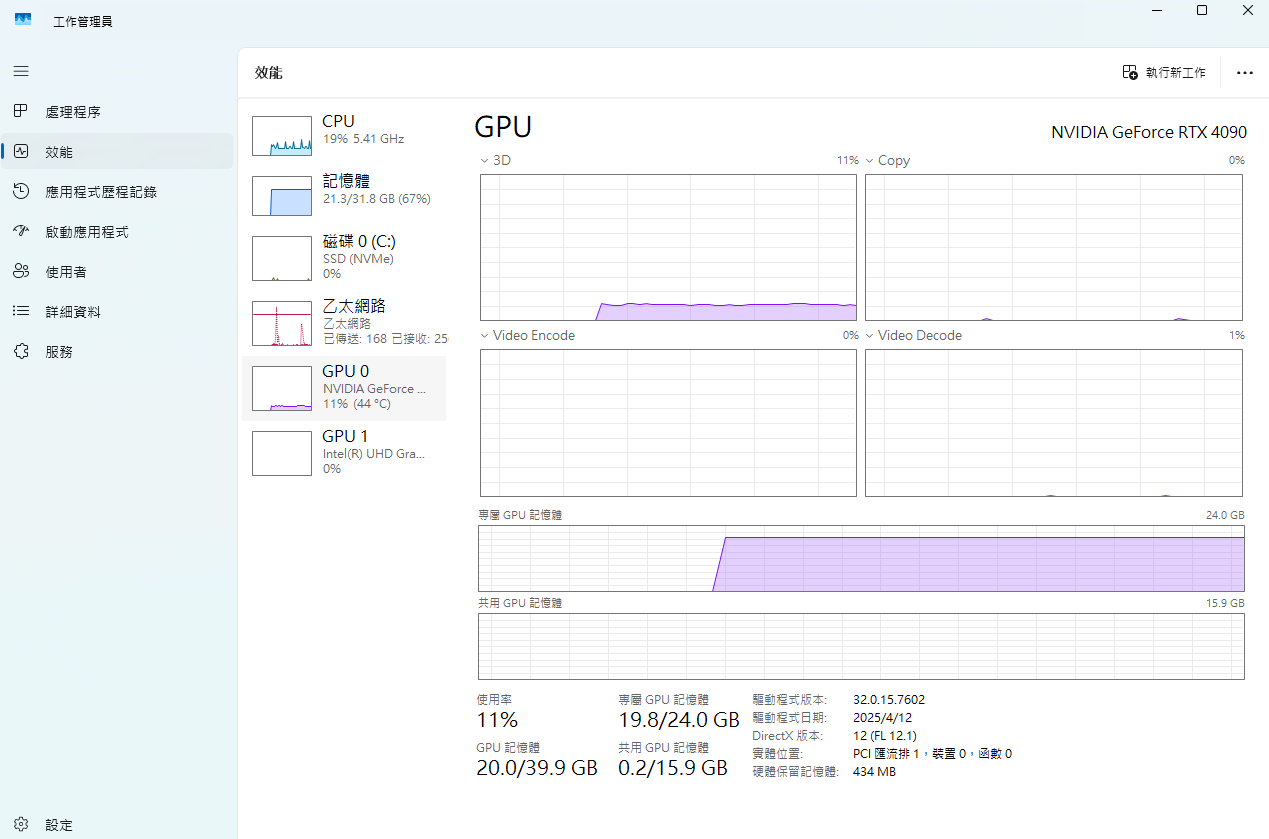


**本地端伺服器硬體資源使用與效能概況評估表**





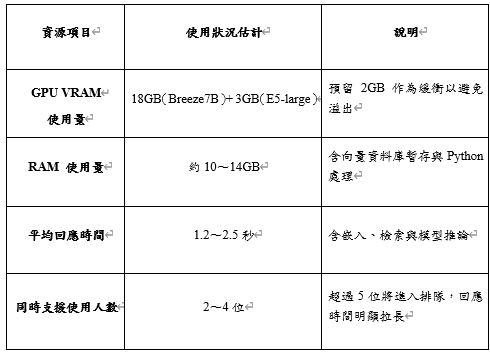

MySQL資料表會保存使用者與系統的對話內容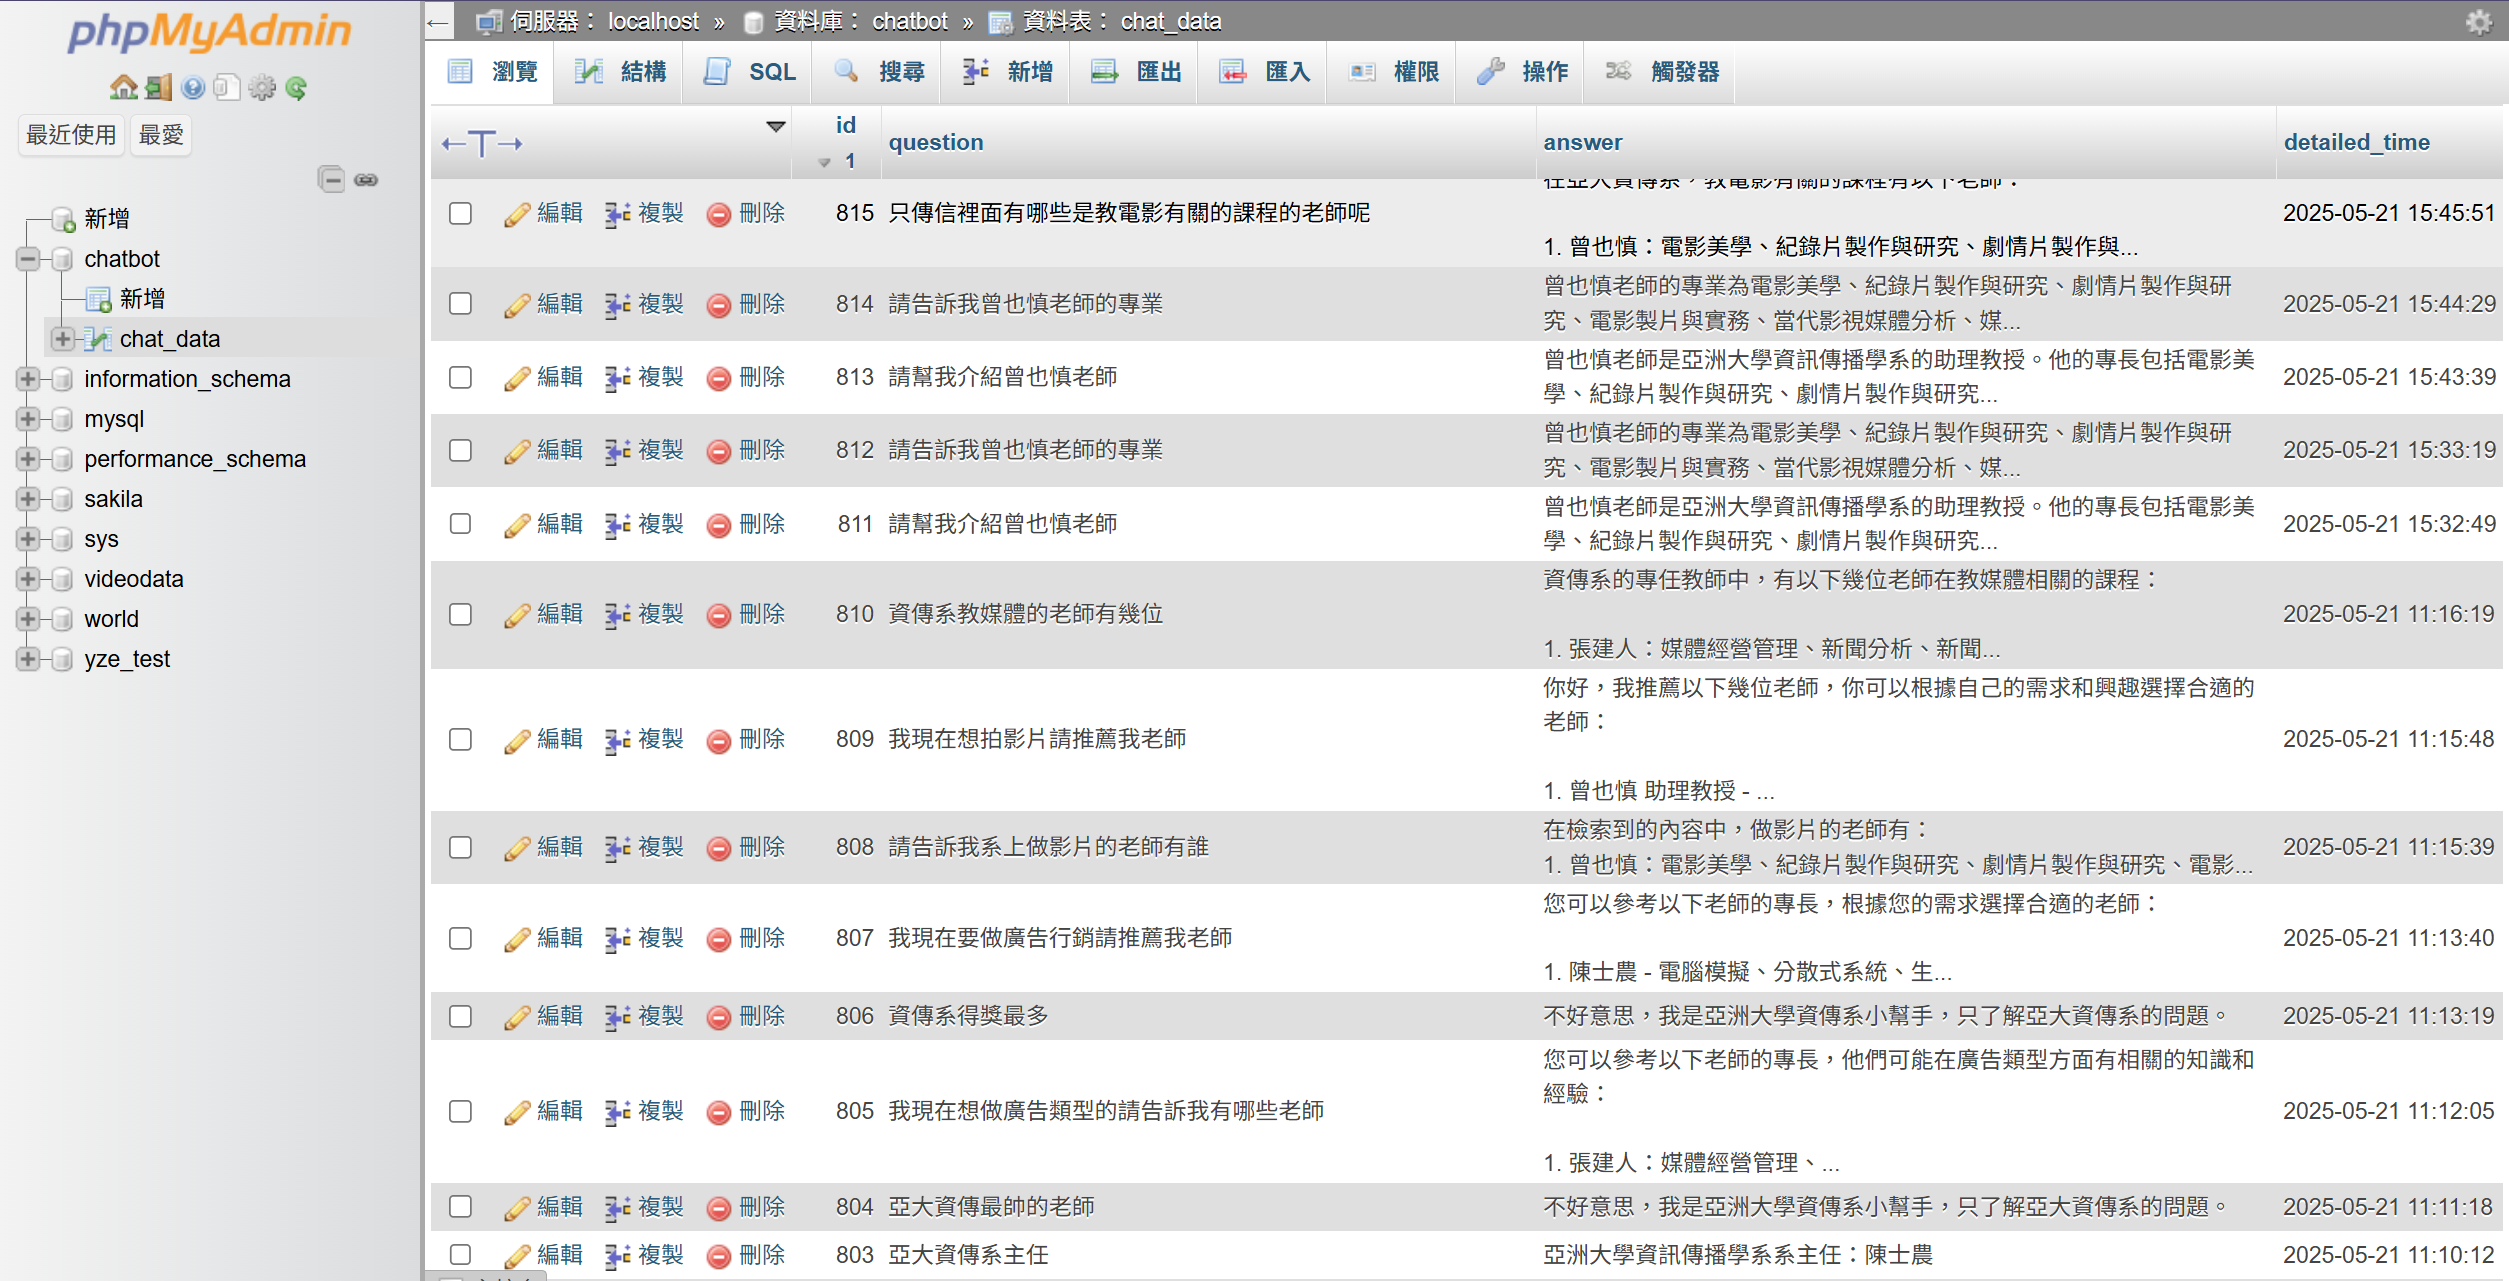

unity數位人物：RAG.CS檔 與後端RAG2.py的通訊連接。

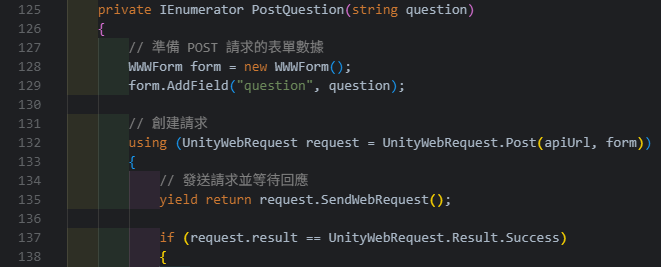



Web網頁版：script.js檔 與後端RAG2.py的通訊連接。

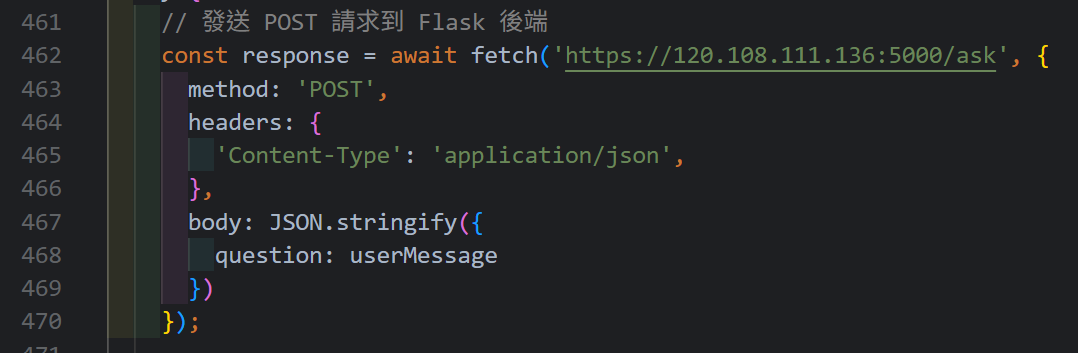